# Healthcare DS Class Project

Savanna Cabrera, Manuel Sanchez, Sienna Lee

## EDA Analysis

Note. I am performing EDA analysis on my beloved VSCode book before I try to do it in Tableau. Tableau is more "on-rails", so this is to make sure I have enough background to know which graphs I would like to try and run. \

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [19]:
#Take in our file and read it into a pandas dataframe
file_name = "glp1_faers_complete_2018_2025.csv"

df = pd.read_csv(file_name, low_memory=False)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (281871, 27)


,ingredient_query,safetyreportid,safetyreportversion,receivedate,receiptdate,occurcountry,primarysourcecountry,reporter_qualification,serious,hospitalized,death,life_threatening,disabling,congenital_anomaly,other_serious,patient_age,patient_age_unit,patient_age_years,patient_sex,patient_weight_kg,matching_medicinal_products,matching_indications,matching_routes,matching_drug_roles,reaction_terms,n_reactions,n_drugs_in_report
0,Dulaglutide,14340470,1,20180101,20180101,US,US,Physician,0,0,0,0,0,0,0,NaN,NaN,NaN,Female,64.85,TRULICITY,TYPE 2 DIABETES MELLITUS,050,Concomitant,Decreased appetite | Dysgeusia | Insomnia | Na...,6,10
1,Dulaglutide,14341380,1,20180102,20180102,US,US,Consumer/non-health professional,0,0,0,0,0,0,0,66.0,801.0,66.0,Female,NaN,TRULICITY,TYPE 2 DIABETES MELLITUS,058,Suspect,Blood glucose decreased | Malaise,2,3
2,Dulaglutide,14342154,2,20180102,20180105,IL,IL,Physician,1,1,0,1,0,0,1,NaN,NaN,NaN,Male,NaN,TRULICITY,TYPE 2 DIABETES MELLITUS,065,Suspect,Diabetic ketoacidosis | Nausea,2,4
3,Dulaglutide,14342607,1,20180102,20180102,US,US,Consumer/non-health professional,0,0,0,0,0,0,0,NaN,NaN,NaN,Female,NaN,TRULICITY,PRODUCT USED FOR UNKNOWN INDICATION,065,Suspect,Abdominal distension | Abdominal pain upper,2,2
4,Dulaglutide,14342663,1,20180102,20180102,US,US,Consumer/non-health professional,0,0,0,0,0,0,0,64.0,801.0,64.0,Female,NaN,TRULICITY,TYPE 2 DIABETES MELLITUS,058,Suspect,Chills | Nausea,2,1


In [20]:
#Review column names and data types
print(df.columns.tolist())
df.dtypes


['ingredient_query', 'safetyreportid', 'safetyreportversion', 'receivedate', 'receiptdate', 'occurcountry', 'primarysourcecountry', 'reporter_qualification', 'serious', 'hospitalized', 'death', 'life_threatening', 'disabling', 'congenital_anomaly', 'other_serious', 'patient_age', 'patient_age_unit', 'patient_age_years', 'patient_sex', 'patient_weight_kg', 'matching_medicinal_products', 'matching_indications', 'matching_routes', 'matching_drug_roles', 'reaction_terms', 'n_reactions', 'n_drugs_in_report']


ingredient_query                object
safetyreportid                   int64
safetyreportversion              int64
receivedate                      int64
receiptdate                      int64
occurcountry                    object
primarysourcecountry            object
reporter_qualification          object
serious                          int64
hospitalized                     int64
death                            int64
life_threatening                 int64
disabling                        int64
congenital_anomaly               int64
other_serious                    int64
patient_age                    float64
patient_age_unit               float64
patient_age_years              float64
patient_sex                     object
patient_weight_kg              float64
matching_medicinal_products     object
matching_indications            object
matching_routes                 object
matching_drug_roles             object
reaction_terms                  object
n_reactions              

## Basic Cleanup for EDA Analysis

In [ ]:
df["receivedate"] = pd.to_datetime(df["receivedate"].astype(str), format="%Y%m%d", errors="coerce")
df["receiptdate"] = pd.to_datetime(df["receiptdate"].astype(str), format="%Y%m%d", errors="coerce")
df["report_year"] = df["receivedate"].dt.year
df["age_clean"] = df["patient_age_years"].where(df["patient_age_years"].between(0, 120))
# Keep the latest available version, then preserve every ingredient match.
latest = df[df.safetyreportversion.eq(df.groupby("safetyreportid").safetyreportversion.transform("max"))].copy()
scalar_fields = ["receivedate", "receiptdate", "hospitalized", "patient_age_years", "patient_sex", "n_drugs_in_report", "n_reactions"]
assert not latest.groupby("safetyreportid")[scalar_fields].nunique(dropna=False).gt(1).any().any(), "Conflicting report-level fields require review."
reports = latest.drop_duplicates("safetyreportid").set_index("safetyreportid").copy()
def combine_tokens(values):
    return " | ".join(sorted({token.strip() for value in values.dropna() for token in str(value).split("|") if token.strip()})) or np.nan
for col in ["ingredient_query", "matching_medicinal_products", "matching_indications", "matching_routes", "matching_drug_roles", "reaction_terms"]:
    reports[col] = latest.groupby("safetyreportid")[col].agg(combine_tokens)
reports = reports.reset_index()
print("Drug-report rows:", len(df))
print("Distinct report IDs:", len(reports))
print("Additional ingredient-match rows:", len(df) - len(reports))
print("Duplicate drug/report pairs:", df.duplicated(["ingredient_query", "safetyreportid"]).sum())
print("Reports updated after 2025:", reports.receiptdate.gt(pd.Timestamp("2025-12-31")).sum())

Drug-report rows: 281871
Unique FDA reports: 276902
Rows caused by reports matching multiple drugs: 4969
Duplicate drug/report pairs: 0


## Check missing data


patient_weight_kg         88.31
patient_age_years         40.96
matching_routes           14.43
matching_indications       7.18
reporter_qualification     0.45
patient_sex                0.00
matching_drug_roles        0.00
n_reactions                0.00
n_drugs_in_report          0.00
dtype: float64


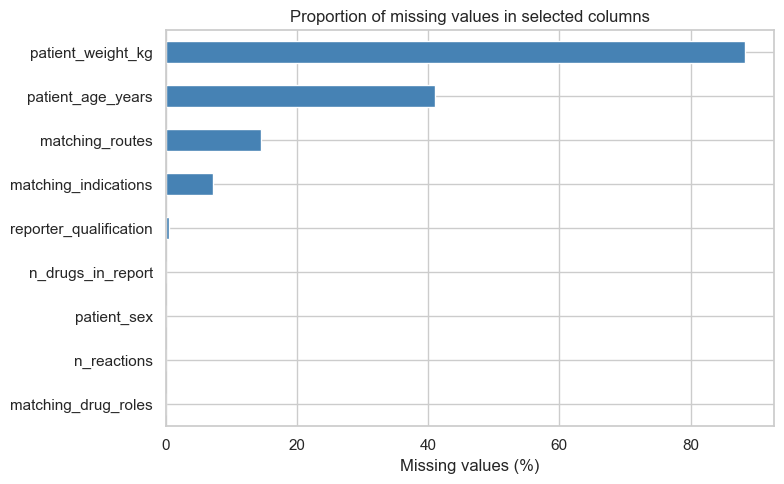

In [22]:
columns_to_check = [
    "patient_age_years",
    "patient_sex",
    "patient_weight_kg",
    "reporter_qualification",
    "matching_indications",
    "matching_routes",
    "matching_drug_roles",
    "n_reactions",
    "n_drugs_in_report"
]

missing = (
    reports[columns_to_check]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(missing.round(2))

plt.figure(figsize=(8, 5))
missing.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Missing values (%)")
plt.title("Proportion of missing values in selected columns")
plt.tight_layout()
plt.show()


Note that patient weight has an extremely large amount of missing NA values. It would probably need to be left out on any modeling due to the high amount of NAs. Patient age may also need to be omitted.

## Investigating Response Variable: Hospitalizations

Counts:
hospitalized
0    243765
1     33137
Name: count, dtype: int64

Percent:
hospitalized
0    88.03
1    11.97
Name: proportion, dtype: float64


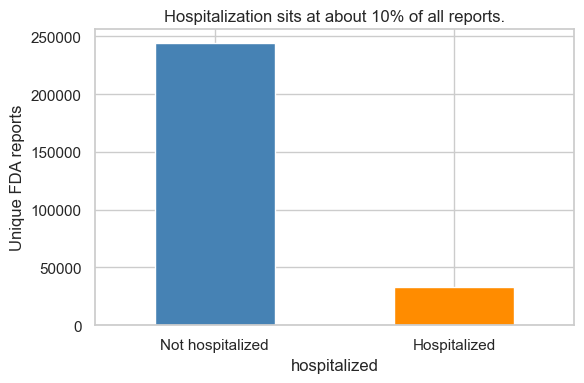

In [23]:
target_counts = reports["hospitalized"].value_counts().sort_index()
target_pct = reports["hospitalized"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(target_counts)
print("\nPercent:")
print(target_pct.round(2))

plt.figure(figsize=(6, 4))
target_counts.rename(index={0: "Not hospitalized", 1: "Hospitalized"}).plot(
    kind="bar", color=["steelblue", "darkorange"], rot=0
)
plt.ylabel("Unique FDA reports")
plt.title("Hospitalization sits at about 10% of all reports.")
plt.tight_layout()
plt.show()


## Let's see the report patterns across drugs


In [24]:
drug_summary = (
    df.groupby("ingredient_query")["hospitalized"]
      .agg(reports="count", hospitalizations="sum", hospitalization_rate="mean")
      .sort_values("reports", ascending=False)
)
drug_summary["hospitalization_pct"] = drug_summary["hospitalization_rate"] * 100

drug_summary[["reports", "hospitalizations", "hospitalization_pct"]].round(2)

,reports,hospitalizations,hospitalization_pct
ingredient_query,,,
Tirzepatide,121302,7463,6.15
Dulaglutide,73876,8942,12.10
Semaglutide,60958,12487,20.48
Liraglutide,20042,5433,27.11
Lixisenatide,3098,207,6.68
Exenatide,2595,544,20.96


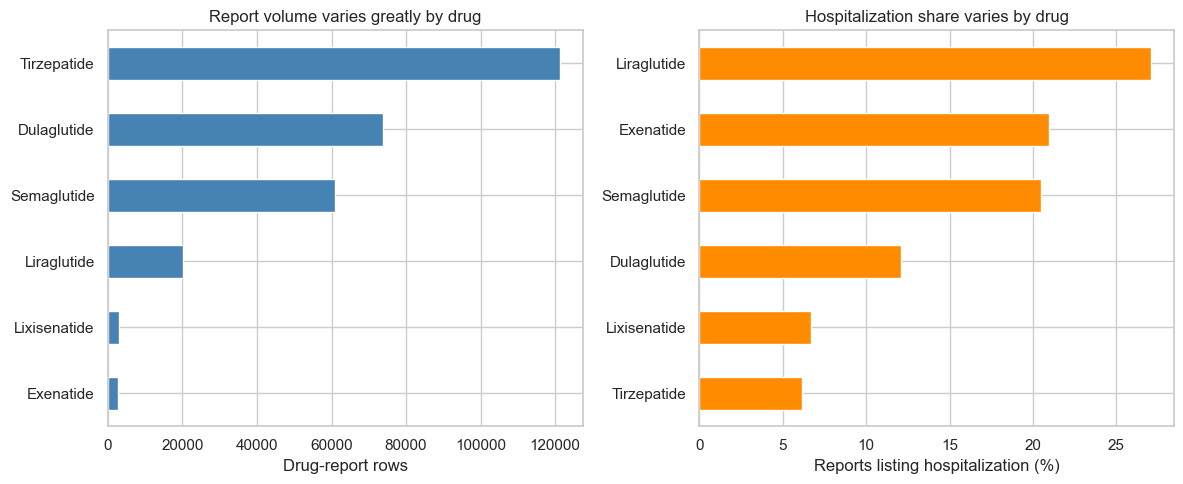

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

drug_summary["reports"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_xlabel("Drug-report rows")
axes[0].set_ylabel("")
axes[0].set_title("Report volume varies greatly by drug")

drug_summary["hospitalization_pct"].sort_values().plot(
    kind="barh", ax=axes[1], color="darkorange"
)
axes[1].set_xlabel("Reports listing hospitalization (%)")
axes[1].set_ylabel("")
axes[1].set_title("Hospitalization share varies by drug")

plt.tight_layout()
plt.show()

From what I see from the two graphs; Tirzepatide has by FAR the most amounts of reports, but the least amount of hospitalizations. However, the drug Liraglutide has less reports, but far more reported hospitalizations. Liraglutide really strikes when it strikes. 

## Time analysis


In [26]:
year_summary = (
    reports.groupby("report_year")["hospitalized"]
           .agg(reports="count", hospitalization_rate="mean")
)
year_summary["hospitalization_pct"] = year_summary["hospitalization_rate"] * 100

year_summary.round(2)


,reports,hospitalization_rate,hospitalization_pct
report_year,,,
2018,13978,0.15,14.59
2019,14777,0.17,16.67
2020,17429,0.15,15.44
2021,19952,0.15,14.62
2022,24726,0.12,11.82
2023,41668,0.10,9.71
2024,55762,0.11,11.12
2025,88610,0.11,11.12


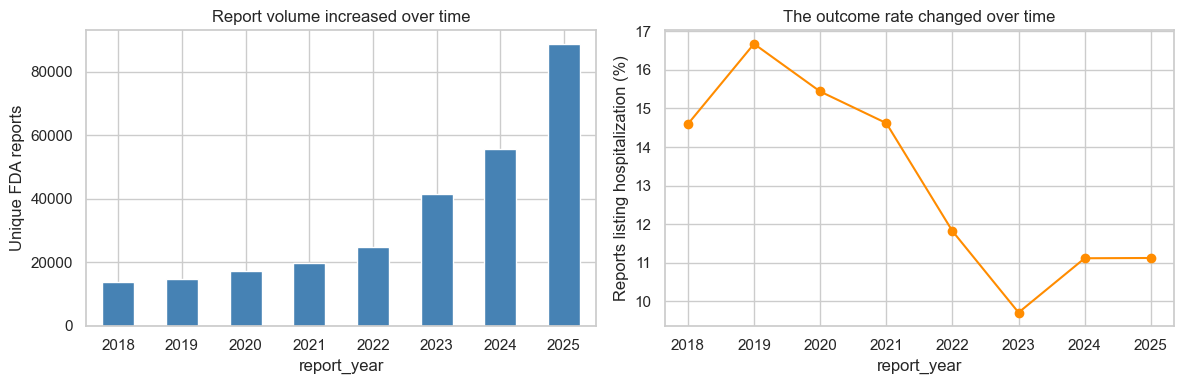

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

year_summary["reports"].plot(
    kind="bar", ax=axes[0], color="steelblue", rot=0
)
axes[0].set_ylabel("Unique FDA reports")
axes[0].set_title("Report volume increased over time")

year_summary["hospitalization_pct"].plot(
    marker="o", ax=axes[1], color="darkorange"
)
axes[1].set_ylabel("Reports listing hospitalization (%)")
axes[1].set_title("The outcome rate changed over time")

plt.tight_layout()
plt.show()

Note that FDA reports have risen as time moved on, but this doesn't mean that the drugs are becoming more dangerous. More users would naturally increase the amount of reports. What's interesting is that despite the rise in users, the hospitalization rate has gone down over time. 

## Drug Composition by Year

Do we see changes over time due to more GLP-1 drugs entering the market?

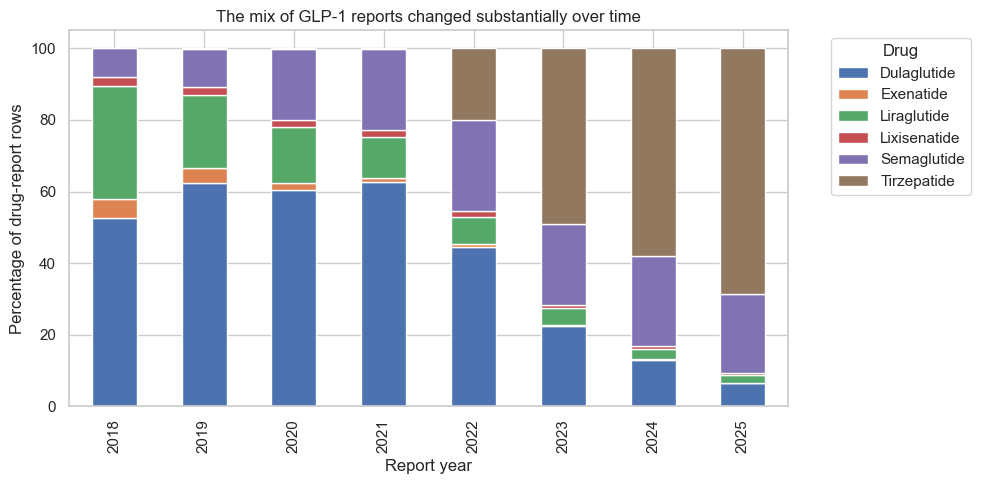

In [28]:
drug_by_year = pd.crosstab(
    df["report_year"],
    df["ingredient_query"],
    normalize="index"
) * 100

drug_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.ylabel("Percentage of drug-report rows")
plt.xlabel("Report year")
plt.title("The mix of GLP-1 reports changed substantially over time")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Exploring Patient Age and Sex
Remember that weight is basically a useless feature.

patient_sex
Female     161406
Male        79264
Unknown     36232
Name: count, dtype: int64

Age summary:
count    163489.0
mean         57.5
std          13.9
min           0.0
25%          48.0
50%          59.0
75%          68.0
max         104.0
Name: age_clean, dtype: float64


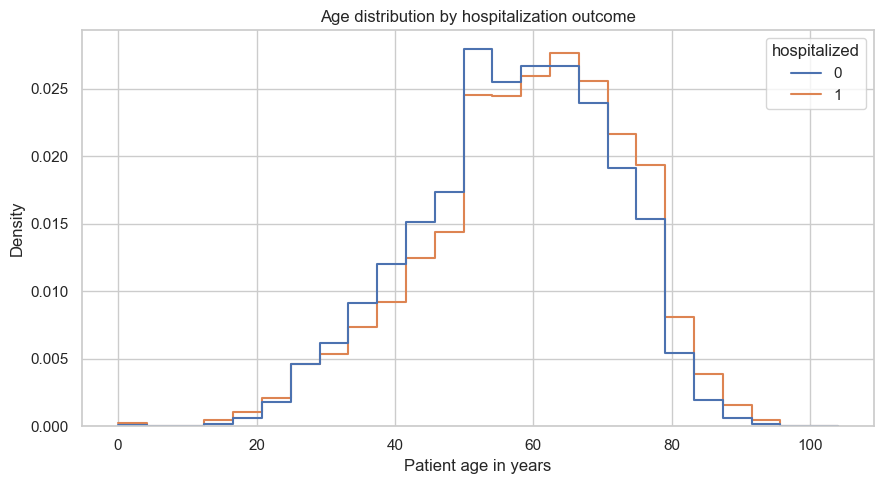

In [29]:
print(reports["patient_sex"].value_counts(dropna=False))
print("\nAge summary:")
print(reports["age_clean"].describe().round(1))

plt.figure(figsize=(9, 5))
sns.histplot(
    data=reports,
    x="age_clean",
    hue="hospitalized",
    bins=25,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)
plt.xlabel("Patient age in years")
plt.title("Age distribution by hospitalization outcome")
plt.tight_layout()
plt.show()


Looks like age between folks who were hospitalized do not differ significantly from those who were not hospitalized. Majority of adversely effected patients (with known age) hovers around 40-80, mean roughly 60. 

## Hospitalizations by Age Group

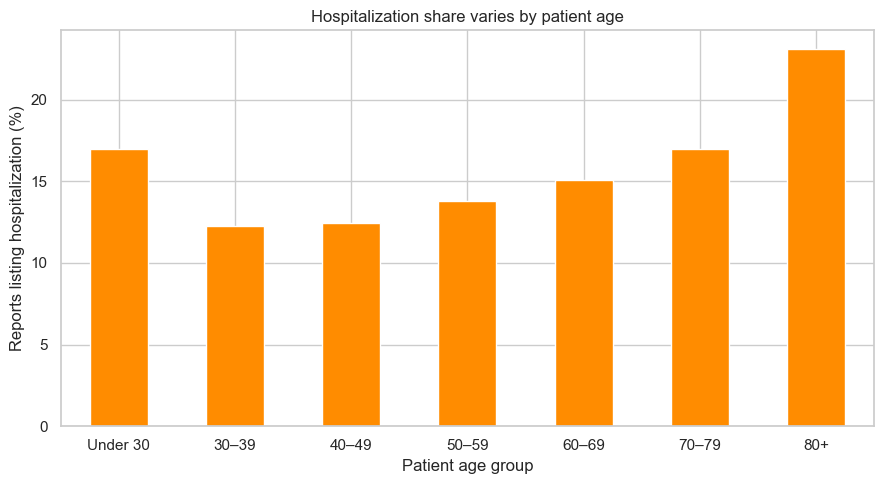

In [34]:
reports["age_group"] = pd.cut(
    reports["age_clean"],
    bins=[0, 29, 39, 49, 59, 69, 79, 120],
    labels=["Under 30", "30–39", "40–49", "50–59",
            "60–69", "70–79", "80+"],
    include_lowest=True
)

age_summary = (
    reports.groupby("age_group", observed=True)["hospitalized"]
    .agg(reports="count", hospitalization_rate="mean")
)

age_summary["hospitalization_pct"] = (
    age_summary["hospitalization_rate"] * 100
)

age_summary["hospitalization_pct"].plot(
    kind="bar",
    figsize=(9, 5),
    color="darkorange",
    rot=0
)

plt.ylabel("Reports listing hospitalization (%)")
plt.xlabel("Patient age group")
plt.title("Hospitalization share varies by patient age")
plt.tight_layout()
plt.show()

## Explore how reporter type fits into this, if any.

In [30]:
reporter_summary = (
    reports.assign(
        reporter=reports["reporter_qualification"].fillna("Unknown")
    )
    .groupby("reporter")["hospitalized"]
    .agg(reports="count", hospitalization_rate="mean")
)
reporter_summary["hospitalization_pct"] = reporter_summary["hospitalization_rate"] * 100

reporter_summary.sort_values("reports", ascending=False).round(2)

,reports,hospitalization_rate,hospitalization_pct
reporter,,,
Consumer/non-health professional,226723,0.08,8.26
Physician,21624,0.30,30.00
Other health professional,18108,0.23,22.86
Pharmacist,7570,0.33,33.39
Lawyer,1619,0.54,53.86
Unknown,1258,0.31,30.92


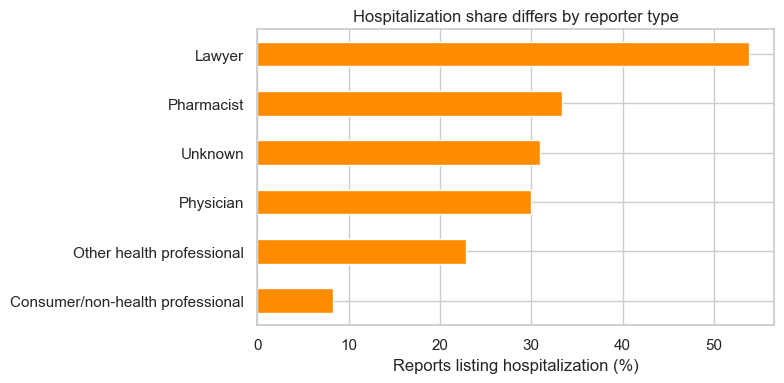

In [31]:
reporter_summary["hospitalization_pct"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="darkorange"
)
plt.xlabel("Reports listing hospitalization (%)")
plt.ylabel("")
plt.title("Hospitalization share differs by reporter type")
plt.tight_layout()
plt.show()


LMAO. When a drug causes hospitalization, a lawyer usually fills out the FAERs report, which makes sense. Then it's Pharmacist. Though there's a lot of unknowns here so it may behoove us to ignore reporter column. 

## Hospitalization by drug role
Was GLP-1 the cause or was it a concomitant med?

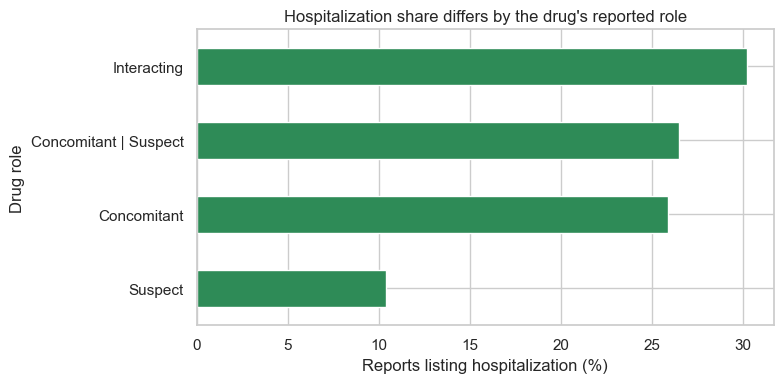

In [35]:
role_summary = (
    df.groupby("matching_drug_roles")["hospitalized"]
    .agg(reports="count", hospitalization_rate="mean")
)

# Keep categories with at least 100 reports
role_summary = role_summary[role_summary["reports"] >= 100]
role_summary["hospitalization_pct"] = (
    role_summary["hospitalization_rate"] * 100
)

role_summary["hospitalization_pct"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    color="seagreen"
)

plt.xlabel("Reports listing hospitalization (%)")
plt.ylabel("Drug role")
plt.title("Hospitalization share differs by the drug's reported role")
plt.tight_layout()
plt.show()

Lots of interacting medications causing issues. Does this track with report complexity?

## Report Complexity versus Hospitalization

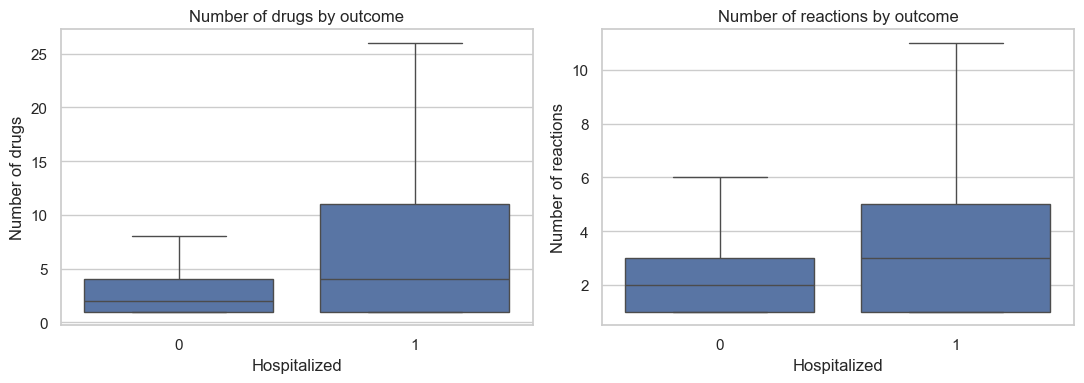

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(
    data=reports,
    x="hospitalized",
    y="n_drugs_in_report",
    showfliers=False,
    ax=axes[0]
)
axes[0].set_xlabel("Hospitalized")
axes[0].set_ylabel("Number of drugs")
axes[0].set_title("Number of drugs by outcome")

sns.boxplot(
    data=reports,
    x="hospitalized",
    y="n_reactions",
    showfliers=False,
    ax=axes[1]
)
axes[1].set_xlabel("Hospitalized")
axes[1].set_ylabel("Number of reactions")
axes[1].set_title("Number of reactions by outcome")

plt.tight_layout()
plt.show()

Hospitalized reports generally contained more medications and more reported reactions than non-hospitalized reports. The difference was especially pronounced for the number of medications, suggesting that report complexity may help predict whether a submitted report lists hospitalization. However, the distributions overlap substantially, so these variables should be combined with other patient and report characteristics.

In [37]:
reports.groupby("hospitalized")[
    ["n_drugs_in_report", "n_reactions"]
].agg(["count", "median", "mean", "std"]).round(2)

n_drugs_in_report                     n_reactions               \
                         count median  mean    std       count median  mean   
hospitalized                                                                  
0                       243765    2.0  4.31   6.41      243765    2.0  2.44   
1                        33137    4.0  9.14  24.70       33137    3.0  4.39   

                    
               std  
hospitalized        
0             2.47  
1             5.47

## Common reaction terms
This is where I suspect the meat of the data is.

reaction_terms
Incorrect dose administered                         31904
Nausea                                              30269
Injection site pain                                 22174
Diarrhoea                                           17666
Vomiting                                            16457
Off label use                                       16330
Blood glucose increased                             15588
Extra dose administered                             11303
Constipation                                         9992
Decreased appetite                                   9660
Weight decreased                                     9199
Drug ineffective                                     9193
Fatigue                                              8833
Injection site haemorrhage                           7899
Inappropriate schedule of product administration     7627
Name: count, dtype: int64


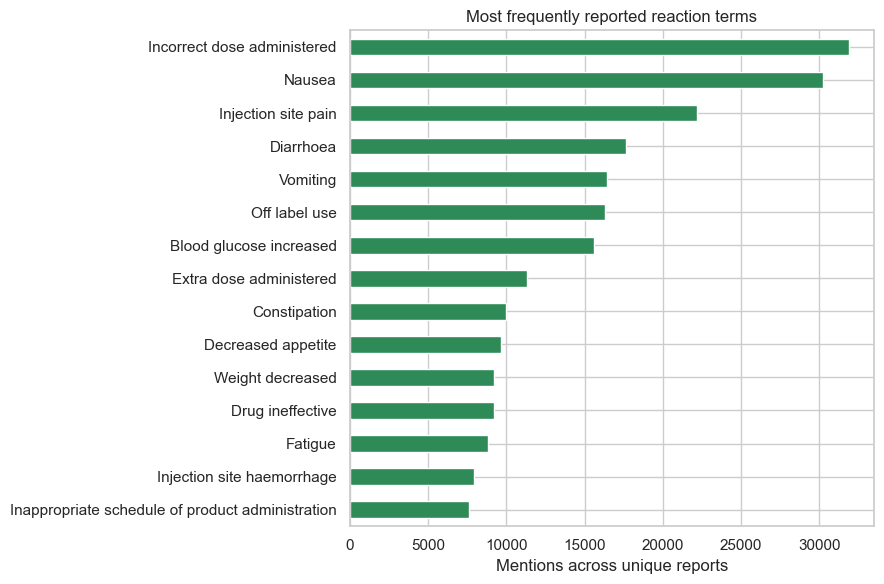

In [32]:
top_reactions = (
    reports["reaction_terms"]
    .dropna()
    .str.split("|", regex=False)
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)

print(top_reactions)

top_reactions.sort_values().plot(
    kind="barh", figsize=(9, 6), color="seagreen"
)
plt.xlabel("Mentions across unique reports")
plt.ylabel("")
plt.title("Most frequently reported reaction terms")
plt.tight_layout()
plt.show()
